# Testando um modelo simples de aprendizado de um Datase aleatório

## Imports

In [1]:
import IPython.display as ipd
import json
import numpy as np
import matplotlib.pyplot as plt
import random
import soundfile as sf
import pandas as pd

from fm_synth import FMSynth, SAMPLE_RATE


## Gerando um dataset aleatório

### Rodando aleatoriamente e salvando o resultado

In [2]:
duracao_amostras = 4
tamanho_dataset = 5000
precisao_decimal = 3
base_path = 'dataset_big2'

## Lendo o dataset no formato pandas

### Lendo as variáveis de entrada

In [3]:
samples = []
for i in range(tamanho_dataset):
    signal = sf.read(f"{base_path}/sample_{i+1}.wav")
    samples.append(signal)

samples = pd.DataFrame(samples)

In [4]:
samples = samples.drop(columns=[1])
samples.head()

,0
0,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05..."
1,"[-3.0517578125e-05, 0.0, 9.1552734375e-05, 0.0..."
2,"[-3.0517578125e-05, 0.0, 6.103515625e-05, 0.00..."
3,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 0.0, 3.0517..."
4,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 3.051757812..."


### Lendo o alvo

In [5]:
with open(f"{base_path}/parameters.json", "r") as f:
    target = f.read()

target = json.loads(target)
target = target[:tamanho_dataset]

target = pd.DataFrame(target)
target.head()

,id,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,1,33.972,0.167,4.101,3.000,2.078,5.000,0.000,1.500,2.812,0.167,8.000,0.769,0.113,0.426,0.774,0.375
1,2,309.502,3.000,1.829,1.000,1.443,1.000,0.610,5.000,0.000,0.667,3.941,0.969,0.158,0.235,0.332,0.422
2,3,394.895,4.000,1.619,1.500,0.000,0.125,1.001,0.250,4.914,1.500,0.158,0.720,0.365,0.510,0.407,0.722
3,4,30.844,0.125,2.717,0.486,2.273,5.000,0.000,2.000,0.000,0.667,3.433,0.799,0.322,0.329,0.749,0.446
4,5,55.182,2.000,2.455,8.000,0.000,0.167,0.000,0.125,0.000,4.000,5.627,0.794,0.268,0.590,0.213,0.384


In [6]:
# Imprimindo o nome das colunas
print(target.columns)

Index(['id', 'frequencia_base', 'frequency1', 'beta2', 'frequency2', 'beta3',
       'frequency3', 'beta4', 'frequency4', 'beta5', 'frequency5',
       'beta_carrier', 'amplitude_carrier', 'attack', 'decay', 'sustain',
       'release'],
      dtype='object')


In [7]:
target = target.drop(columns=["id"])
target.head()

,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,33.972,0.167,4.101,3.000,2.078,5.000,0.000,1.500,2.812,0.167,8.000,0.769,0.113,0.426,0.774,0.375
1,309.502,3.000,1.829,1.000,1.443,1.000,0.610,5.000,0.000,0.667,3.941,0.969,0.158,0.235,0.332,0.422
2,394.895,4.000,1.619,1.500,0.000,0.125,1.001,0.250,4.914,1.500,0.158,0.720,0.365,0.510,0.407,0.722
3,30.844,0.125,2.717,0.486,2.273,5.000,0.000,2.000,0.000,0.667,3.433,0.799,0.322,0.329,0.749,0.446
4,55.182,2.000,2.455,8.000,0.000,0.167,0.000,0.125,0.000,4.000,5.627,0.794,0.268,0.590,0.213,0.384


### Juntando alvo e features

In [8]:
ds = pd.concat([samples, target], axis=1)
ds.head()

,0,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05...",33.972,0.167,4.101,3.000,2.078,5.000,0.000,1.500,2.812,0.167,8.000,0.769,0.113,0.426,0.774,0.375
1,"[-3.0517578125e-05, 0.0, 9.1552734375e-05, 0.0...",309.502,3.000,1.829,1.000,1.443,1.000,0.610,5.000,0.000,0.667,3.941,0.969,0.158,0.235,0.332,0.422
2,"[-3.0517578125e-05, 0.0, 6.103515625e-05, 0.00...",394.895,4.000,1.619,1.500,0.000,0.125,1.001,0.250,4.914,1.500,0.158,0.720,0.365,0.510,0.407,0.722
3,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 0.0, 3.0517...",30.844,0.125,2.717,0.486,2.273,5.000,0.000,2.000,0.000,0.667,3.433,0.799,0.322,0.329,0.749,0.446
4,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 3.051757812...",55.182,2.000,2.455,8.000,0.000,0.167,0.000,0.125,0.000,4.000,5.627,0.794,0.268,0.590,0.213,0.384


In [9]:
ds.shape

(5000, 17)

## Separando treino e teste

In [10]:
train = ds.sample(frac=0.75, random_state=0)
test = ds.drop(train.index)

In [11]:
train.head(5)

,0,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
398,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05...",49.367,5.000,0.000,8.00,0.000,8.000,1.997,0.667,2.192,0.667,4.027,0.616,0.154,0.305,0.664,0.175
3833,"[-3.0517578125e-05, 0.0, 0.0, 6.103515625e-05,...",101.533,8.000,0.000,3.00,0.000,1.500,0.000,0.333,1.539,0.125,6.478,0.922,0.240,0.540,0.102,0.197
4836,"[-3.0517578125e-05, -3.0517578125e-05, 0.0, 0....",31.651,0.763,0.000,4.00,2.026,0.200,2.605,4.000,0.000,0.667,8.000,0.510,0.387,0.498,0.861,0.566
4572,"[-3.0517578125e-05, 0.000885009765625, 0.00418...",1570.702,0.500,1.456,0.25,0.000,0.200,0.682,0.667,0.000,0.667,1.064,0.607,0.018,0.071,0.249,0.755
636,"[-3.0517578125e-05, 0.000457763671875, 0.00265...",494.022,1.500,0.015,0.25,0.213,0.125,0.000,3.000,1.229,0.200,0.206,0.635,0.010,0.047,0.234,0.668


In [12]:
x = pd.DataFrame(train[0])
x.head()

,0
398,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05..."
3833,"[-3.0517578125e-05, 0.0, 0.0, 6.103515625e-05,..."
4836,"[-3.0517578125e-05, -3.0517578125e-05, 0.0, 0...."
4572,"[-3.0517578125e-05, 0.000885009765625, 0.00418..."
636,"[-3.0517578125e-05, 0.000457763671875, 0.00265..."


In [13]:
x = np.array(x[0].values.tolist())
x[0]

array([-3.05175781e-05,  0.00000000e+00,  0.00000000e+00, ...,
        1.83105469e-04,  1.22070312e-04,  6.10351562e-05])

In [14]:
len(x[0])

64000

In [15]:
y = train.drop(columns=[0])
y.head()

,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
398,49.367,5.000,0.000,8.00,0.000,8.000,1.997,0.667,2.192,0.667,4.027,0.616,0.154,0.305,0.664,0.175
3833,101.533,8.000,0.000,3.00,0.000,1.500,0.000,0.333,1.539,0.125,6.478,0.922,0.240,0.540,0.102,0.197
4836,31.651,0.763,0.000,4.00,2.026,0.200,2.605,4.000,0.000,0.667,8.000,0.510,0.387,0.498,0.861,0.566
4572,1570.702,0.500,1.456,0.25,0.000,0.200,0.682,0.667,0.000,0.667,1.064,0.607,0.018,0.071,0.249,0.755
636,494.022,1.500,0.015,0.25,0.213,0.125,0.000,3.000,1.229,0.200,0.206,0.635,0.010,0.047,0.234,0.668


In [16]:
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler()
y_train_norm = scaler_y.fit_transform(y)
print(y_train_norm)

[[-0.64989835  1.69942861 -0.7231     ... -0.03091371  0.72436602
  -1.15211273]
 [-0.58067922  3.19639451 -0.7231     ...  1.35301844 -1.74920087
  -1.05066567]
 [-0.67340573 -0.41478623 -0.7231     ...  1.10567737  1.59143484
   0.65087818]
 ...
 [-0.57404471 -0.43574375  0.53023039 ...  1.37657473 -0.26594101
  -0.94921861]
 [ 0.08102783 -0.71218346 -0.7231     ... -0.37247994 -1.45871081
   0.05602952]
 [-0.68781587 -0.62935134 -0.7231     ... -0.79060412 -1.25624804
   1.43478728]]


### Redimensionando a entrada

In [17]:
print(x.shape)
x = x.reshape((x.shape[0], x.shape[1], 1))
print(x.shape)

print(x[0])

# frame_length = 2048

# dataset = []
# for sample in x:
#   length = sample.shape[0]
#   num_frames = int(length / frame_length)
#   amostras_uteis = num_frames * frame_length
#   sample_cutted = sample[:amostras_uteis]
#   sample_cutted = sample_cutted.reshape(num_frames, frame_length)
#   dataset.append(sample_cutted)

# x = np.array(dataset)
# print(x.shape)
# x[0:5]

(3750, 64000)
(3750, 64000, 1)
[[-3.05175781e-05]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 ...
 [ 1.83105469e-04]
 [ 1.22070312e-04]
 [ 6.10351562e-05]]


In [18]:
# Gravando x num arquivo .npy
np.save(f"{base_path}/x_train_big2.npy", x)
np.save(f"{base_path}/y_train_big2.npy", y_train_norm)

## Construindo o modelo

In [19]:
from keras.layers import TimeDistributed, Dense, Input, Lambda, BatchNormalization, Concatenate, Conv1D, ZeroPadding1D, Flatten, Dropout, MaxPooling1D
from keras.models import Model
from tensorflow.keras.utils import plot_model
from keras.callbacks import EarlyStopping
import tensorflow as tf

2025-10-04 20:32:48.312508: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-04 20:32:48.343267: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759620768.359424   19611 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759620768.363862   19611 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759620768.377045   19611 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [20]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [21]:
# Configurando para não alocar diretamente toda a memória da GPU (alocar conforme necessário)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Aloca memória conforme necessário
    except RuntimeError as e:
        print(e)

In [22]:
def regressor(input_dims, output_dims, activation, bias):
  input_layer = Input(shape=[input_dims])

  x_0 = Dense(int(input_dims/2), activation=activation, use_bias=bias, kernel_regularizer="l2")(input_layer)
  x_0 = Dropout(0.2)(x_0)
  x_2 = Dense(int(input_dims/4), activation=activation, use_bias=bias)(x_0)
  saidas = Dense(output_dims, activation=None, name='regressor_saidas', use_bias=bias)(x_2)

  return Model(input_layer, saidas, name="regressor")

def build_models(input_len, input_dims, output_dims, activation, bias):
  
  # Camadas de entrada
  input_layer = Input(shape=(input_len, input_dims))

  x_n = BatchNormalization()(input_layer)

  # Features 1
  extrator1 = Conv1D(
    filters=8,
    kernel_size=4,
    strides=1,
    activation='relu',
    input_shape=(input_len, 1),
    kernel_regularizer="l2",
    use_bias=True,
  )
  pooling1 = MaxPooling1D(pool_size=16)

  features1 = extrator1(x_n)
  features1 = pooling1(features1)

  extrator1_2 = Conv1D(
    filters=16,
    kernel_size=8,
    strides=1,
    activation='relu',
    input_shape=(input_len, 1),
    kernel_regularizer="l2",
    use_bias=True,
  )
  pooling1_2 = MaxPooling1D(pool_size=16)

  features1_2 = extrator1_2(features1)
  features1_2 = pooling1_2(features1_2)

  extrator1_3 = Conv1D(
    filters=32,
    kernel_size=16,
    strides=1,
    activation='relu',
    input_shape=(input_len, 1),
    kernel_regularizer="l2",
    use_bias=True,
  )
  pooling1_2 = MaxPooling1D(pool_size=16)

  features1_3 = extrator1_3(features1_2)
  features1_2 = pooling1_2(features1_2)

  features1_flatten1 = Flatten()(features1_3)

  features1_flatten1_normalized = BatchNormalization()(features1_flatten1)

  # Regrssão
  regressao = regressor(features1_flatten1_normalized.shape[1], output_dims, activation, bias)

  saida = regressao(features1_flatten1)
  
  return (
      Model(input_layer, saida, name="complete"),
      Model(input_layer, features1_flatten1, name="projecao"),
      Model(features1_flatten1, saida, name="regressao")
  )

model, features, regression = build_models(x.shape[1], x.shape[2], y_train_norm.shape[1], 'relu', False)
# model, features = build_models(x.shape[1], x.shape[2], y.shape[1], 'relu', False)
model.compile(optimizer='adamax', loss='mse', metrics=['mae', 'mse'])
# plot_model(model, show_shapes=True, expand_nested=True)

I0000 00:00:1759620770.544673   19611 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2795 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/sergio/@pessoal/fmsynth/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


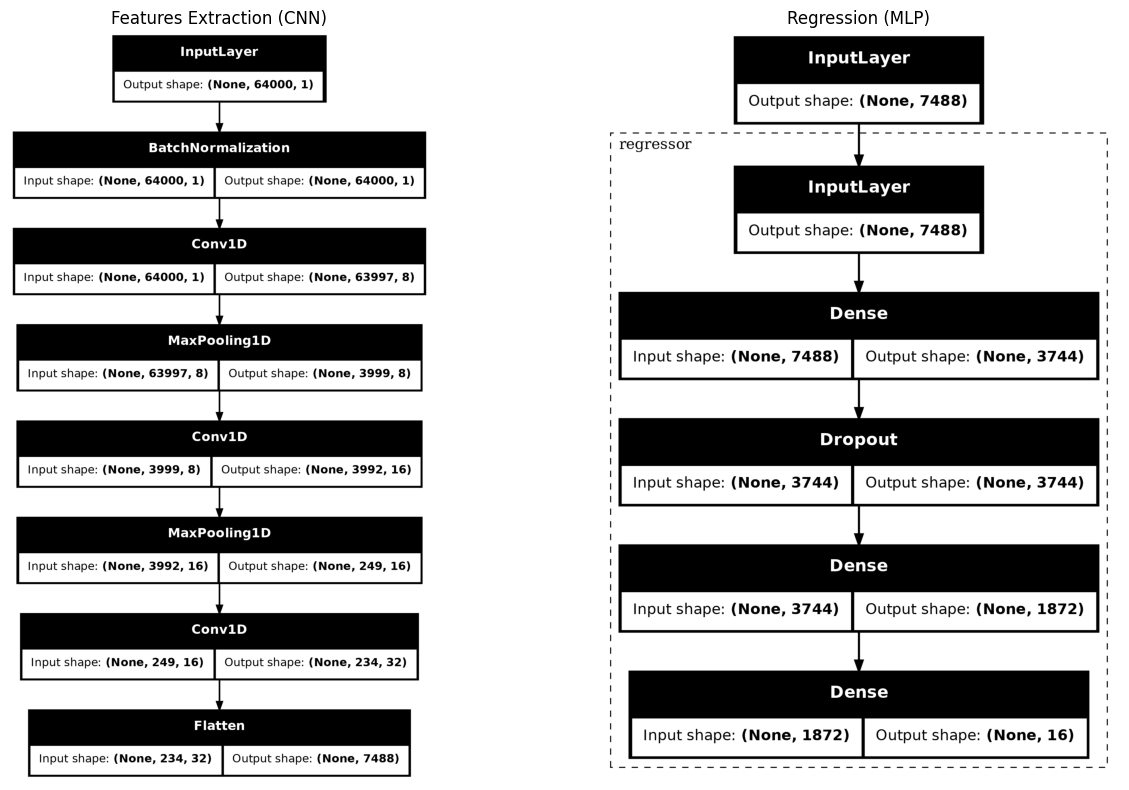

In [23]:
# 1) Gere as imagens
plot_model(features, to_file="projecao.png", show_shapes=True, rankdir="TB", dpi=200)
plot_model(regression,    to_file="regressao.png", show_shapes=True, expand_nested=True, rankdir="TB", dpi=200)

# 2) (Opcional) Exiba lado a lado no notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(mpimg.imread("projecao.png"));  axes[0].set_title("Features Extraction (CNN)"); axes[0].axis("off")
axes[1].imshow(mpimg.imread("regressao.png")); axes[1].set_title("Regression (MLP)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [24]:
# Callback para recuperar o melhor peso, e parar quando ficar três épocas sem melhora
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Treinando o modelo
history = model.fit(x, y_train_norm, epochs=200, validation_split = 0.2, callbacks=[callback])

Epoch 1/200


I0000 00:00:1759620775.585609   19885 service.cc:152] XLA service 0x7fdfa000d3a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759620775.585712   19885 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-10-04 20:32:55.639995: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1759620775.784190   19885 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-10-04 20:32:58.158033: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=1,k3=0} for conv %cudnn-conv.8 = (f32[1,8,1,4]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,32,1,64000]{3,2,1,0} %bitcast.5727, f32[8,32,1,63997]{3,2,1,0} %bitcast.5734), window={size=1x63997}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_ta

 1/94 ━━━━━━━━━━━━━━━━━━━━ 9:24 6s/step - loss: 51.2844 - mae: 0.8241 - mse: 1.0208

I0000 00:00:1759620780.479711   19885 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 212ms/step - loss: 13.1231 - mae: 0.7760 - mse: 1.2110 - val_loss: 6.7424 - val_mae: 0.7404 - val_mse: 0.8322
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - loss: 5.5930 - mae: 0.6731 - mse: 0.7533 - val_loss: 4.7585 - val_mae: 0.6900 - val_mse: 0.7557
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - loss: 4.1922 - mae: 0.6524 - mse: 0.7216 - val_loss: 3.7164 - val_mae: 0.6518 - val_mse: 0.7121
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - loss: 3.3616 - mae: 0.6370 - mse: 0.6988 - val_loss: 3.0330 - val_mae: 0.6204 - val_mse: 0.6821
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - loss: 2.7948 - mae: 0.6266 - mse: 0.6850 - val_loss: 2.5635 - val_mae: 0.6169 - val_mse: 0.6787
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - loss: 2.3686 - mae: 0.6108 - mse: 0.6655 - val_loss: 2.1927 - val_mae: 0.6061 - val_mse: 0.6593
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - loss: 2.0535 - mae: 0.6059 - mse: 0.6591 - 

In [25]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
68,0.605630,0.486908,0.485500,0.704881,0.538898,0.584645,68
69,0.601567,0.483637,0.479863,0.707390,0.517069,0.584792,69
70,0.595488,0.480113,0.473243,0.704596,0.519874,0.582636,70
71,0.587964,0.476984,0.465856,0.713758,0.532843,0.591136,71
72,0.591196,0.479058,0.466989,0.730240,0.523192,0.603754,72


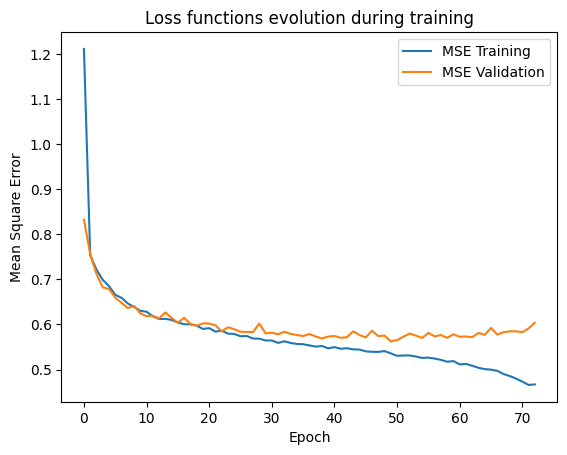

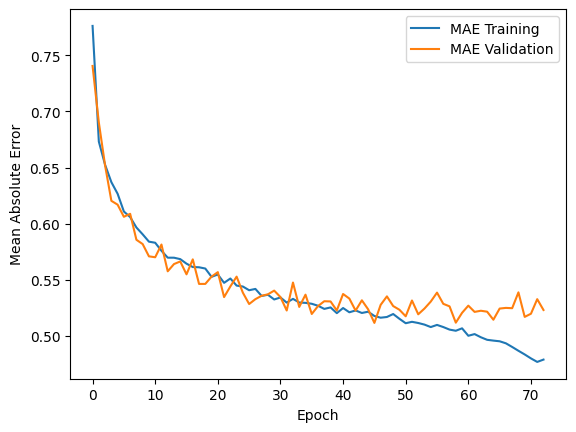

In [26]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure()
plt.title("Loss functions evolution during training")
plt.xlabel('Epoch')
plt.ylabel('Mean Square Error')
plt.plot(hist['epoch'], hist['mse'], label='MSE Training')
plt.plot(hist['epoch'], hist['val_mse'], label = 'MSE Validation')
plt.legend()

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.plot(hist['epoch'], hist['mae'], label='MAE Training')
plt.plot(hist['epoch'], hist['val_mae'], label = 'MAE Validation')
plt.legend()

plt.show()

## Prevendo a amostra de teste

### Ajustando a base de teste

In [27]:
x_t = pd.DataFrame(test[0])
x_t.head()

,0
0,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05..."
7,"[-3.0517578125e-05, 0.0, 6.103515625e-05, 0.00..."
16,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 0.0, 3.0517..."
21,"[-3.0517578125e-05, 0.0, 0.0001220703125, 0.00..."
24,"[-3.0517578125e-05, 0.0, 0.0, 3.0517578125e-05..."


In [28]:
x_t = np.array(x_t[0].values.tolist())
x_t[0]

array([-3.05175781e-05,  0.00000000e+00,  0.00000000e+00, ...,
       -3.05175781e-04, -2.13623047e-04, -1.22070312e-04])

In [29]:
len(x_t[0])

64000

In [30]:
y_t = test.drop(columns=[0])
y_t.head()

,frequencia_base,frequency1,beta2,frequency2,beta3,frequency3,beta4,frequency4,beta5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,33.972,0.167,4.101,3.000,2.078,5.000,0.000,1.500,2.812,0.167,8.000,0.769,0.113,0.426,0.774,0.375
7,597.649,0.667,3.062,0.125,0.913,0.500,0.000,0.500,0.000,0.200,0.467,0.904,0.484,0.200,0.726,0.753
16,43.094,0.356,0.000,1.500,2.798,0.667,4.933,1.317,0.000,0.255,8.000,0.580,0.470,0.303,0.220,0.767
21,363.104,0.250,2.389,4.000,0.000,0.667,0.522,3.000,2.782,0.333,1.296,0.904,0.157,0.270,0.832,0.205
24,35.348,3.000,4.261,0.333,0.000,6.000,2.130,0.125,2.262,4.000,8.000,0.573,0.115,0.491,0.748,0.421


In [31]:
# Gravando x_t e y_t num arquivo .npy
np.save(f"{base_path}/x_test_big2.npy", x_t)
np.save(f"{base_path}/y_test_big2.npy", y_t)

### Chamando o modelo para predição

In [32]:
y_pred_norm = model.predict(x_t)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [33]:
y_pred = scaler_y.inverse_transform(y_pred_norm)

In [34]:
y_pred = pd.DataFrame(y_pred)
y_pred.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,174.815369,1.994807,2.317742,2.371723,1.975578,2.239715,1.563514,2.291897,1.716161,2.080152,6.539797,0.677001,0.122347,0.457968,0.780071,0.342494
1,761.963684,1.383438,0.693064,1.343184,0.544979,1.228924,0.166923,0.676680,0.151637,1.278751,0.505343,0.689735,0.473191,0.308357,0.764838,0.661592
2,84.397163,2.275979,1.921563,2.242513,2.367393,1.007243,1.663121,1.660085,1.506436,2.525025,6.234407,0.676130,0.467841,0.317310,0.230311,0.681016
3,420.055450,1.476651,1.199735,1.583307,0.541294,1.392771,0.986470,1.338364,0.991075,1.460487,2.106171,0.701856,0.187003,0.271359,0.834894,0.220433
4,162.619934,1.815418,2.163503,2.053763,0.700439,4.180261,1.594048,2.739402,1.818638,2.382514,5.429739,0.676229,0.117607,0.489053,0.765212,0.385527


### Calculando erro de teste

In [35]:
mse = tf.keras.losses.MSE(y_t, y_pred).numpy().mean()
mae = tf.keras.losses.MAE(y_t, y_pred).numpy().mean()
rmse = np.sqrt(mse)

In [36]:
print(f"RMSE Test: {rmse}")
print(f"MSE Test: {mse}")
print(f"MAE Test: {mae}")

RMSE Test: 34.4483528137207
MSE Test: 1186.68896484375
MAE Test: 6.984533786773682


### Salvando o modelo

In [37]:
model.save('model_conv_1_sec_v1_3.keras')

### Salvando o scaler

In [38]:
# Salvando o scaller_y
import joblib
joblib.dump(scaler_y, 'scaler_y_conv_1_sec_v1_3.save')

['scaler_y_conv_1_sec_v1_3.save']